In [1]:
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import os
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm
import rasterio
import numpy as np

In [2]:
s1_pre_folder = './bs/sentinel1_pre/'
s1_post_folder = './bs/sentinel1_post/'
s2_pre_folder = './bs/sentinel2_pre/'
s2_post_folder = './bs/sentinel2_post/'
mask_folder = './bs/masks/'
aux_folder = './bs/aux/'

ds_metadata = pd.read_csv("./bs/meta.csv")

## Визуализация Sentinel-1

(3, 512, 512)
1.15
0.0
0.1
1.86
0.0
0.9


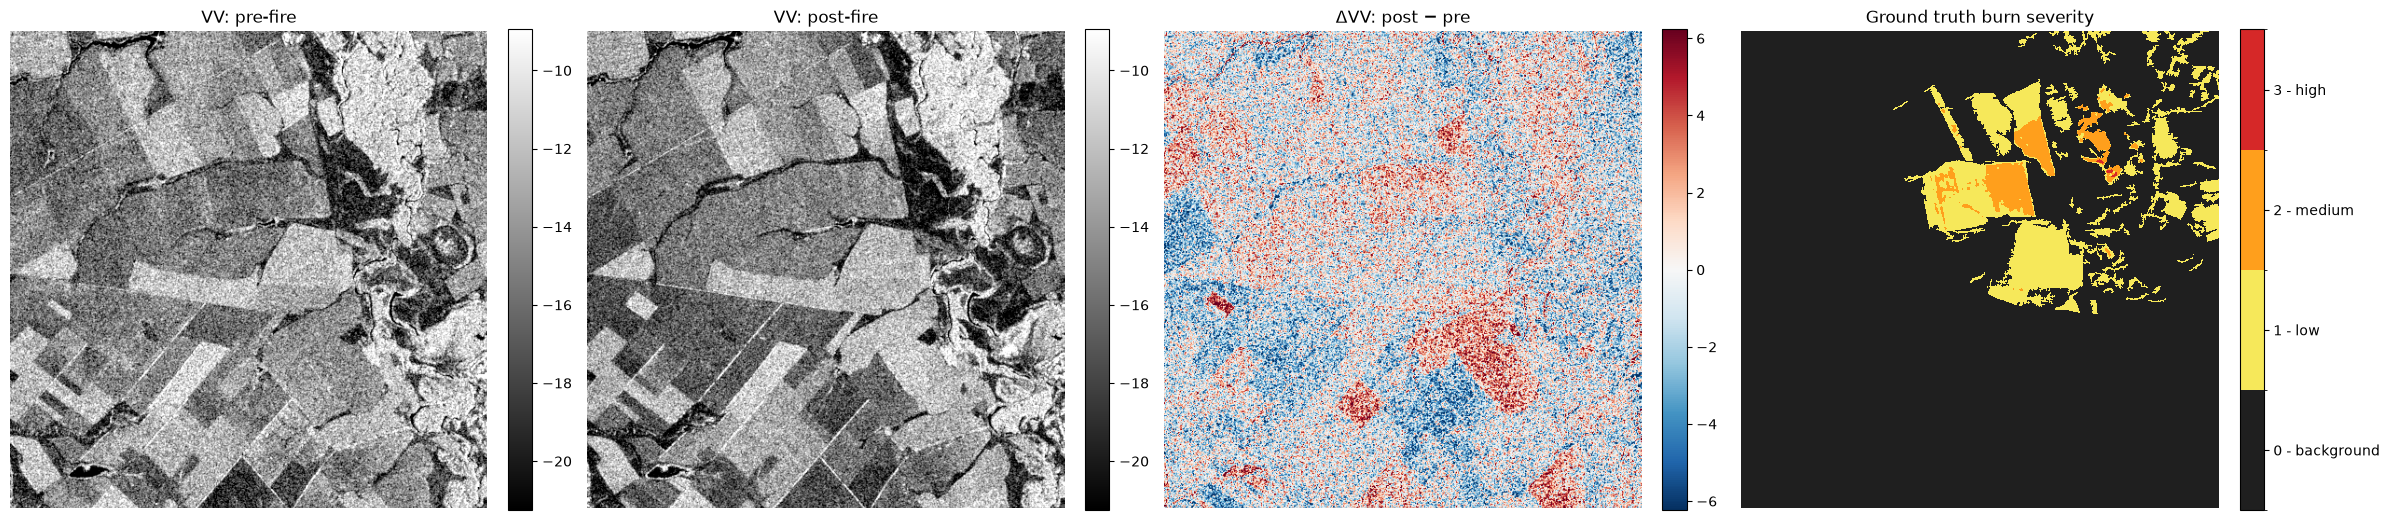

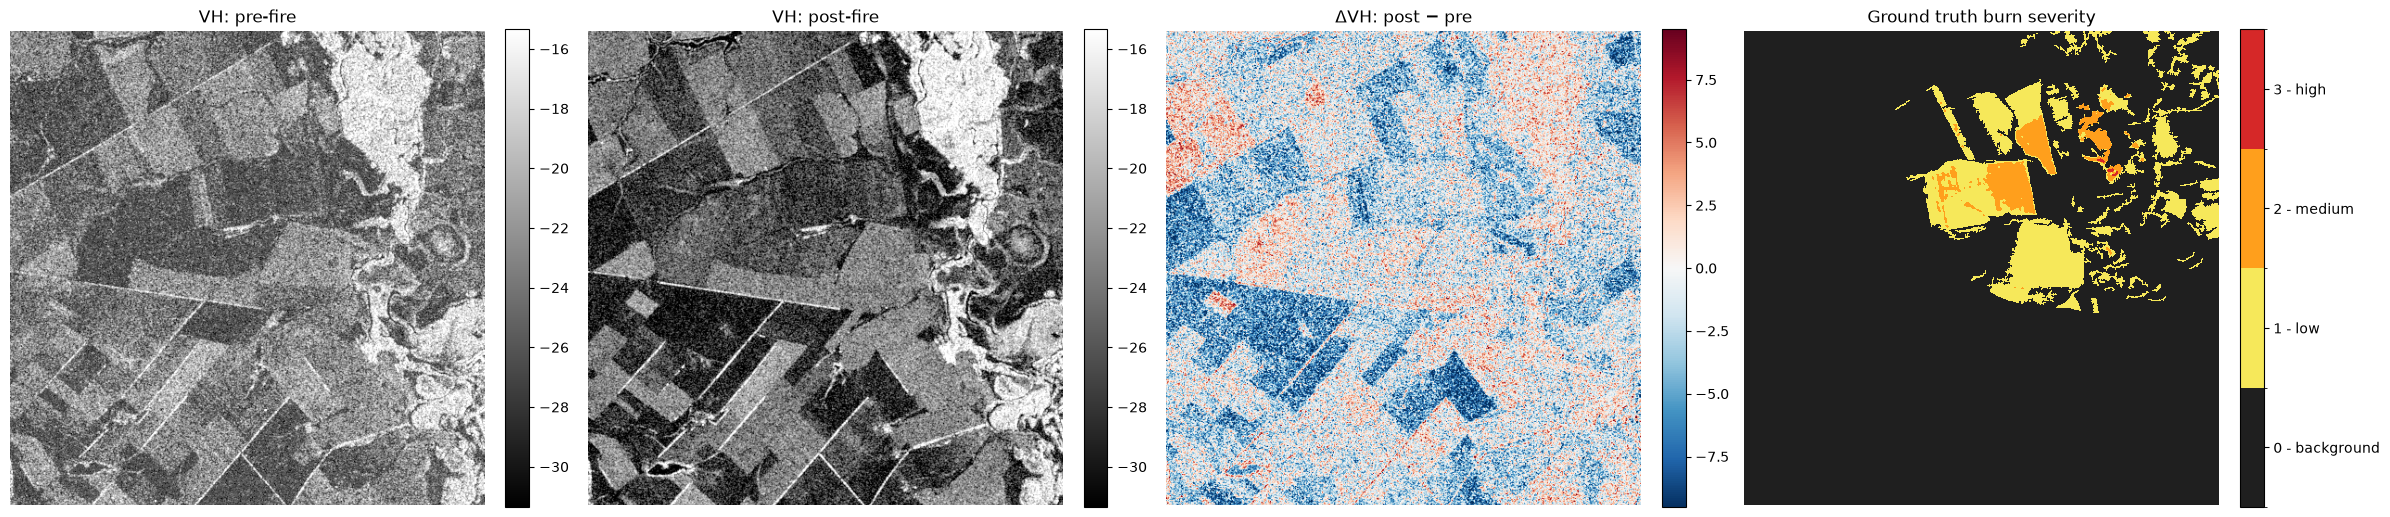

In [3]:
class_colors = [
    "#1f1f1f",
    "#f6e85a", 
    "#ff9f1c", 
    "#d62828",  
]

mask_cmap = ListedColormap(class_colors)
mask_norm = BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5],
    ncolors=mask_cmap.N,
)

idx = 67
s1_pre_prefix = "_Sentinel-1_pre"
s1_post_prefix = "_Sentinel-1_post"
s2_pre_prefix = "_Sentinel-2_pre"
s2_post_prefix = "_Sentinel-2_post"
mask_prefix = "_MASK"
aux_prefix = "_AUX"

pre_path = s1_pre_folder + ds_metadata.iloc[idx]["chip_id"] + s1_pre_prefix + ".tif"
post_path = s1_post_folder + ds_metadata.iloc[idx]["chip_id"] + s1_post_prefix + ".tif"
mask_path = mask_folder + ds_metadata.iloc[idx]["chip_id"] + mask_prefix + ".tif"
aux_path = aux_folder +  ds_metadata.iloc[idx]["chip_id"] + aux_prefix + ".tif"

with rasterio.open(mask_path) as src:
    gt_mask = src.read(1).astype(np.uint8)
    
with rasterio.open(pre_path) as src:
    s1_pre = src.read().astype(np.float32) / 100

with rasterio.open(post_path) as src:
    s1_post = src.read().astype(np.float32) / 100

with rasterio.open(aux_path) as src:
    aux = src.read().astype(np.float32) / 100

vv_pre, vh_pre = s1_pre[0], s1_pre[1]
vv_post, vh_post = s1_post[0], s1_post[1]

dvv = vv_post - vv_pre
dvh = vh_post - vh_pre

print(aux.shape)
print(aux[0].min())
print(aux[1].min())
print(aux[2].min())

print(aux[0].max())
print(aux[1].max())
print(aux[2].max())

def show_pre_post_diff_with_mask(
    pre,
    post,
    diff,
    gt_mask,
    channel_name,
    q_low=2,
    q_high=98,
):
    assert pre.shape == post.shape == diff.shape == gt_mask.shape, (
        f"Shapes must match, got: "
        f"pre={pre.shape}, post={post.shape}, "
        f"diff={diff.shape}, mask={gt_mask.shape}"
    )

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    combined = np.concatenate([pre.ravel(), post.ravel()])
    combined = combined[np.isfinite(combined)]

    lo, hi = np.percentile(combined, [q_low, q_high])

    im0 = axes[0].imshow(pre, cmap="gray", vmin=lo, vmax=hi)
    axes[0].set_title(f"{channel_name}: pre-fire")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(post, cmap="gray", vmin=lo, vmax=hi)
    axes[1].set_title(f"{channel_name}: post-fire")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    valid_diff = diff[np.isfinite(diff)]
    max_abs = np.percentile(np.abs(valid_diff), q_high)

    im2 = axes[2].imshow(
        diff,
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
    )
    axes[2].set_title(f"Δ{channel_name}: post − pre")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    mask_for_plot = np.ma.masked_equal(gt_mask, 255)

    im3 = axes[3].imshow(
        mask_for_plot,
        cmap=mask_cmap,
        norm=mask_norm,
        interpolation="nearest",
    )
    axes[3].set_title("Ground truth burn severity")
    axes[3].axis("off")

    colorbar = plt.colorbar(
        im3,
        ax=axes[3],
        ticks=[0, 1, 2, 3],
        fraction=0.046,
        pad=0.04,
    )
    colorbar.ax.set_yticklabels([
        "0 - background",
        "1 - low",
        "2 - medium",
        "3 - high",
    ])

    plt.tight_layout()
    plt.show()


show_pre_post_diff_with_mask(
    vv_pre,
    vv_post,
    dvv,
    gt_mask,
    "VV",
)

show_pre_post_diff_with_mask(
    vh_pre,
    vh_post,
    dvh,
    gt_mask,
    "VH",
)

## Проверка на валидность S1pre ^ S1post

In [6]:
def read_s1_valid_mask(path: str) -> np.ndarray:
    with rasterio.open(path) as src:
        s1 = src.read([1, 2]).astype(np.float32)

    vv = s1[0]
    vh = s1[1]

    finite = np.isfinite(vv) & np.isfinite(vh)

    fill_value = (
        np.isclose(vv, 0.0, atol=1e-6)
        & np.isclose(vh, 0.0, atol=1e-6)
    )

    return finite & ~fill_value


def check_s1_chip(chip_id: str) -> dict:
    pre_path = os.path.join(
        s1_pre_folder,
        f"{chip_id}_Sentinel-1_pre.tif",
    )

    post_path = os.path.join(
        s1_post_folder,
        f"{chip_id}_Sentinel-1_post.tif",
    )

    result = {
        "chip_id": chip_id,
        "keep_s1": False,
        "valid_pre_fraction": 0.0,
        "valid_post_fraction": 0.0,
        "valid_intersection_fraction": 0.0,
        "error": None,
    }

    try:
        if not os.path.exists(pre_path):
            result["error"] = f"Missing pre: {pre_path}"
            return result

        if not os.path.exists(post_path):
            result["error"] = f"Missing post: {post_path}"
            return result

        valid_pre = read_s1_valid_mask(pre_path)
        valid_post = read_s1_valid_mask(post_path)

        if valid_pre.shape != valid_post.shape:
            result["error"] = (
                f"Shape mismatch: pre={valid_pre.shape}, "
                f"post={valid_post.shape}"
            )
            return result

        valid_intersection = valid_pre & valid_post

        result["valid_pre_fraction"] = float(valid_pre.mean())
        result["valid_post_fraction"] = float(valid_post.mean())
        result["valid_intersection_fraction"] = float(
            valid_intersection.mean()
        )

        # Строго: отбрасываем весь patch даже при одном NoData pixel.
        result["keep_s1"] = bool(valid_intersection.all())

    except Exception as exc:
        result["error"] = repr(exc)

    return result


quality_rows = [
    check_s1_chip(chip_id)
    for chip_id in tqdm(
        ds_metadata["chip_id"].unique(),
        desc="Filtering S1 chips",
    )
]

s1_quality = pd.DataFrame(quality_rows)

print("Total:", len(s1_quality))
print("Keep:", int(s1_quality["keep_s1"].sum()))
print("Drop:", int((~s1_quality["keep_s1"]).sum()))

display(
    s1_quality[
        [
            "valid_pre_fraction",
            "valid_post_fraction",
            "valid_intersection_fraction",
        ]
    ].describe()
)

C:\Users\lolke\miniconda3\envs\cosmohack\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Filtering S1 chips: 100%|██████████| 224/224 [00:05<00:00, 44.42it/s]

Total: 224
Keep: 176
Drop: 48


,valid_pre_fraction,valid_post_fraction,valid_intersection_fraction
count,224.000000,224.000000,224.000000
mean,0.925590,0.917880,0.872117
std,0.222524,0.231822,0.287278
min,0.018433,0.041721,0.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


In [8]:
valid_chip_ids = set(
    s1_quality.loc[
        s1_quality["keep_s1"],
        "chip_id",
    ]
)

ds_metadata_s1 = ds_metadata[
    ds_metadata["chip_id"].isin(valid_chip_ids)
].copy()

print(f"Before: {len(ds_metadata)}")
print(f"After:  {len(ds_metadata_s1)}")

Before: 224
After:  176


In [38]:
ds_metadata_s1.to_csv("clean_s1.csv")

# некоторые патчи (48 из 224) сентинел-1 имеют дефекты, 
# делающие их непригодными для подачи на вход нейросети.